# Eaton Fire Question Mining — EDA

Run cells top to bottom. Assumes you've already run `collect.py` and `normalize.py`.

In [1]:
import sys, pathlib

# Works whether notebook is opened from notebooks/ or project root
PROJECT_ROOT = pathlib.Path('').resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = str(PROJECT_ROOT / 'data' / 'eaton_pipeline.duckdb')
conn = duckdb.connect(DB_PATH, read_only=True)
print('Connected to', DB_PATH)


Connected to /Users/home/Documents/aims-cs321m/eaton-question-pipeline/data/eaton_pipeline.duckdb


## 1. Overall counts

In [2]:
summary = conn.execute("""
    SELECT 
        COUNT(*) as total_records,
        SUM(CASE WHEN type = 'post' THEN 1 ELSE 0 END) as posts,
        SUM(CASE WHEN type = 'comment' THEN 1 ELSE 0 END) as comments,
        SUM(CASE WHEN is_question = TRUE THEN 1 ELSE 0 END) as questions,
        SUM(CASE WHEN has_question_mark = TRUE THEN 1 ELSE 0 END) as has_question_mark
    FROM records
""").df()
summary

,total_records,posts,comments,questions,has_question_mark
0,5633,5633.0,0.0,3893.0,2812.0


In [3]:
# By subreddit
conn.execute("""
    SELECT subreddit,
           COUNT(*) as total,
           SUM(CASE WHEN type='post' THEN 1 ELSE 0 END) as posts,
           SUM(CASE WHEN is_question=TRUE THEN 1 ELSE 0 END) as questions
    FROM records
    GROUP BY subreddit ORDER BY total DESC
""").df()

,subreddit,total,posts,questions
0,Pasadena,4033,4033.0,2829.0
1,Altadena,1392,1392.0,1004.0
2,losangeles,183,183.0,53.0
3,California,18,18.0,2.0
4,Insurance,7,7.0,5.0


## 2. Post volume over time

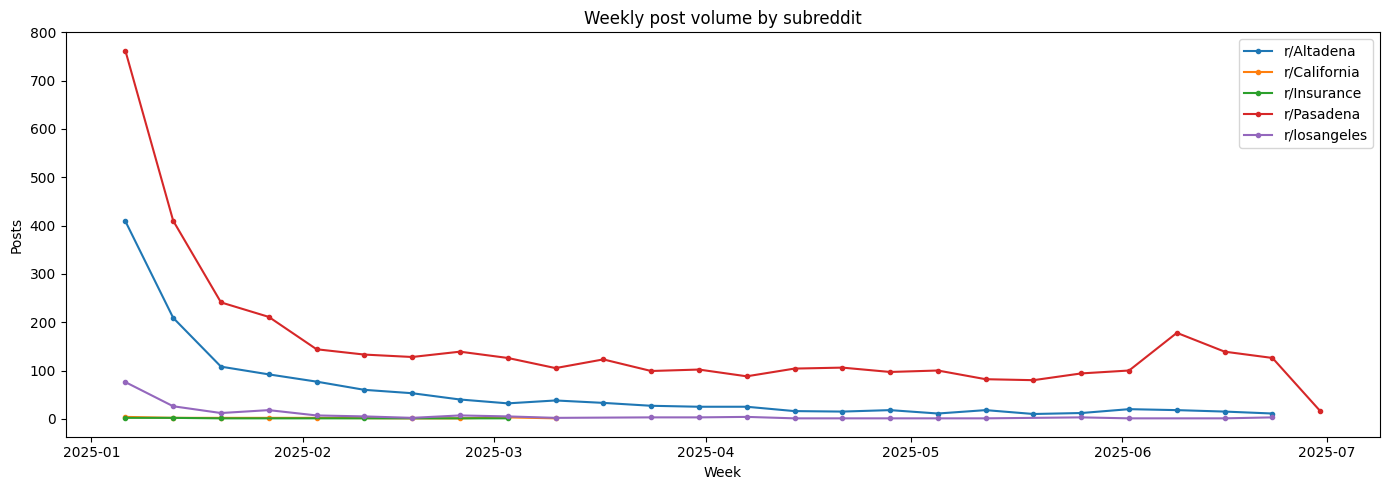

In [4]:
df_time = conn.execute("""
    SELECT 
        DATE_TRUNC('week', created_utc) as week,
        subreddit,
        COUNT(*) as n
    FROM records
    WHERE type = 'post' AND created_utc IS NOT NULL
    GROUP BY week, subreddit
    ORDER BY week, subreddit
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
for sub, grp in df_time.groupby('subreddit'):
    ax.plot(grp['week'], grp['n'], label=f'r/{sub}', marker='o', markersize=3)
ax.set_title('Weekly post volume by subreddit')
ax.set_xlabel('Week')
ax.set_ylabel('Posts')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Top question-survivors by score

In [5]:
top_q = conn.execute("""
    SELECT subreddit, score, created_utc::DATE as date,
           LEFT(COALESCE(body_clean, body), 200) as preview
    FROM records
    WHERE is_question = TRUE
    ORDER BY score DESC NULLS LAST
    LIMIT 20
""").df()

for _, row in top_q.iterrows():
    print(f"[{row['subreddit']}] score={row['score']} date={row['date']}")
    print(f"  {row['preview']}")
    print()

[Pasadena] score=5342 date=2025-01-22 00:00:00
  Can we do this too? r/newjersey has and others are considering it.

[Pasadena] score=3871 date=2025-01-12 00:00:00
  Have you all seen this? How Eaton Fire started

[Pasadena] score=3659 date=2025-01-12 00:00:00
  What’s left of my house/ before photos of my sweet home. I’m here for you guys🧡 we will get through this

[Pasadena] score=3335 date=2025-01-09 00:00:00
  A professional photographer took one last photo of my house before it was fully eviscerated. That’s my car too, we could only take one when we left. Absolutely devastated. Praying for everyone who is 

[Pasadena] score=3180 date=2025-03-29 00:00:00
  Tesla Boycott On Colorado Blvd Well Done Pasadena ✊
A whole block with protesters walking about as well! What a turn out!

[losangeles] score=3130 date=2025-01-14 00:00:00
  OP is trying to return a photo that wind carried to her yard after the Eaton fire. Anyone recognize them? Link to original post on BlueSky: https://bsky.app/

## 4. Program area tag distribution

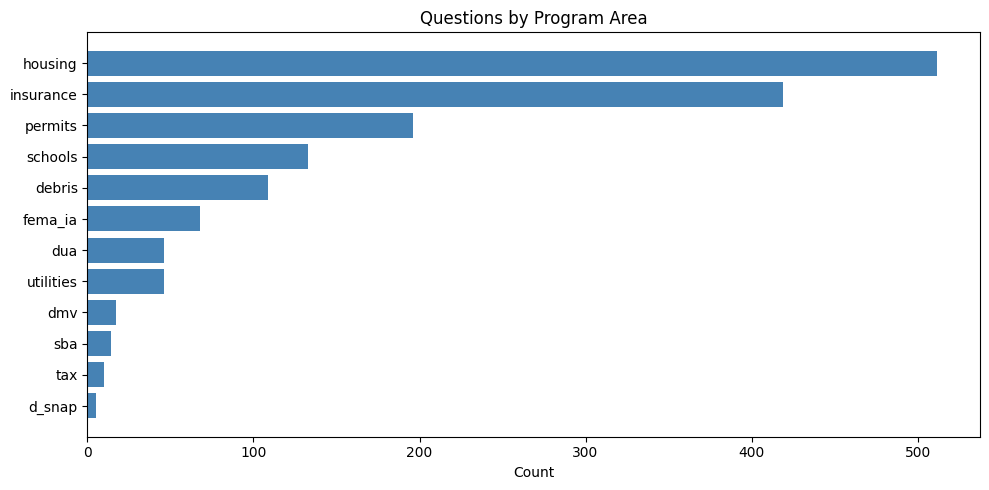

In [6]:
tag_dist = conn.execute("""
    SELECT tag, COUNT(*) as n
    FROM (SELECT unnest(program_area_tags) as tag
          FROM records WHERE is_question = TRUE AND program_area_tags IS NOT NULL)
    GROUP BY tag ORDER BY n DESC
""").df()

if not tag_dist.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(tag_dist['tag'], tag_dist['n'], color='steelblue')
    ax.set_xlabel('Count')
    ax.set_title('Questions by Program Area')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No tags yet — run tag.py first.')


## 5. Language distribution

In [7]:
conn.execute("""
    SELECT lang, COUNT(*) as n
    FROM records WHERE is_question = TRUE AND lang IS NOT NULL
    GROUP BY lang ORDER BY n DESC LIMIT 15
""").df()

,lang,n
0,en,3794
1,unknown,87
2,ca,4
3,af,2
4,es,2
5,da,1
6,sv,1
7,pt,1
8,fr,1


## 6. Cluster size distribution

In [8]:
cluster_df = conn.execute("""
    SELECT cluster_id, cluster_size,
           COALESCE(body_clean, body) as body
    FROM records
    WHERE is_exemplar = TRUE AND cluster_id >= 0
    ORDER BY cluster_size DESC
    LIMIT 20
""").df()

if not cluster_df.empty:
    print(f"Top clusters ({len(cluster_df)} shown):")
    for _, row in cluster_df.iterrows():
        print(f"  [{row['cluster_id']}] size={row['cluster_size']}: {(row['body'] or '')[:120]}")
else:
    print('No clusters yet — run cluster.py first.')

Top clusters (20 shown):
  [86] size=55: Is it that time of the month? Increased PD presence lately As the title says, my friends and I have noticed the streets 
  [11] size=42: Daily Discussion Thread The floor is open, while staying within the subs stated purview. Clean slate each day. Be kind N
  [38] size=19: Need recommendation for a blond colorist in the area? Hi, I’m somewhat new to the area from San Diego and I’m looking fo
  [88] size=17: Illegal firecrackers in my neighborhood Someone in my neighborhood thinks that it ok to be that incredibly inconsiderate
  [125] size=17: Deep Cleaning @ Pasadena City College - Patients Needed Hello everyone! I am a junior dental hygiene student at Pasadena
  [8] size=15: helicopters, police activity, did you see/hear that? & weekly discussion The floor is open, while staying within the sub
  [108] size=14: Update on cat found in Altadena If you keep up with r/pasadena, I have posted this on there too. Hello everyone here is 
  [96] size=13:

## 7. Browse questions for a specific program area

In [9]:
AREA = 'insurance'  # change this

conn.execute(f"""
    SELECT subreddit, score, created_utc::DATE as date,
           LEFT(COALESCE(body_clean, body), 300) as preview
    FROM records
    WHERE is_question = TRUE
      AND list_contains(program_area_tags, '{AREA}')
    ORDER BY score DESC NULLS LAST
    LIMIT 20
""").df()

,subreddit,score,date,preview
0,Pasadena,280,2025-03-23,Sincerely Syria in Old Town Old Town was packe...
1,Pasadena,278,2025-01-13,I feel like a fraud. I’m (30s male) at an Airb...
2,Pasadena,255,2025-01-11,"I am overwhelmed by all the donation drives, I..."
3,Pasadena,237,2025-06-11,"You kicked ICE out of your hotel, Pasadena, he..."
4,Pasadena,234,2025-02-04,My friend lost his Altadena home in the Eaton ...
5,Altadena,231,2025-01-24,anyone else feel like their brain is broken af...
6,Altadena,207,2025-01-11,Ok the anger stage of grief is setting in I’m ...
7,Pasadena,193,2025-06-06,"LAT: Unfortunately, Altadena is for sale: Deve..."
8,Pasadena,180,2025-01-09,Anyone interested in starting a community coll...
9,Pasadena,178,2025-01-21,BE CAREFUL!!! Scammers all around This is just...


---
## 8. Government-services questions — tag-filtered ranking

Filters to questions tagged with any core government-services area,
deduplicates to one exemplar per cluster, ranks by cluster size then score.

In [10]:
# Core government-service tags — edit to focus on a subset
GOVT_TAGS = ['fema_ia', 'sba', 'dua', 'dmv', 'tax', 'd_snap', 'debris', 'permits', 'insurance', 'utilities']
tag_filter = ' OR '.join([f"list_contains(program_area_tags, '{t}')" for t in GOVT_TAGS])

df_govt = conn.execute(f"""
    SELECT cluster_id, cluster_size, program_area_tags, question_type_tags,
           subreddit, score, created_utc::DATE as date,
           COALESCE(body_clean, body) as body
    FROM records
    WHERE is_question = TRUE
      AND ({tag_filter})
      AND (is_exemplar = TRUE OR cluster_id = -1)
    ORDER BY cluster_size DESC NULLS LAST, score DESC NULLS LAST
    LIMIT 200
""").df()

print(f"{len(df_govt)} results (one exemplar per cluster, singletons included)")
df_govt[['cluster_id','cluster_size','program_area_tags','subreddit','date','score']].head(20)


200 results (one exemplar per cluster, singletons included)


,cluster_id,cluster_size,program_area_tags,subreddit,date,score
0,28,12,"[debris, housing]",Pasadena,2025-01-13,3
1,90,11,[permits],Pasadena,2025-06-11,263
2,12,8,"[insurance, housing]",Pasadena,2025-02-04,129
3,77,8,"[insurance, schools]",Pasadena,2025-04-15,100
4,65,8,"[insurance, debris, schools]",Pasadena,2025-05-15,63
5,158,8,"[insurance, housing]",Pasadena,2025-02-14,63
6,170,8,"[insurance, housing]",Altadena,2025-03-10,0
7,94,7,"[insurance, housing]",Pasadena,2025-06-11,85
8,165,6,"[housing, permits]",Altadena,2025-01-22,108
9,132,6,"[insurance, dua, debris, permits]",Altadena,2025-01-22,50


In [11]:
# Full text readout — change .head(N) to browse further down the ranking
for _, row in df_govt.head(30).iterrows():
    sz = row['cluster_size']
    cid = row['cluster_id']
    cluster_label = f"cluster {cid} ({sz} similar)" if cid >= 0 else "singleton"
    print(f"── {cluster_label} | r/{row['subreddit']} | score={row['score']} | {row['date']}")
    print(f"   tags: {row['program_area_tags']}")
    print((row['body'] or '')[:500])
    print()


── cluster 28 (12 similar) | r/Pasadena | score=3 | 2025-01-13 00:00:00
   tags: ['debris' 'housing']
Please wear a N95 or P100 mask when exposed to ash from fires (wear full PPE) Supposed air quality response expert said on the town hall today that wearing an N95 can be more dangerous for your heart and shouldn’t be worn in some cases without talking to your doctor. Do not get confused and use this as an excuse to not wear a mask/goggles and full PPE. Just wanted to remind everyone of the dangers of NOT wearing a mask or proper PPE when responding to fire debris. There is lead, asbestos, plasti

── cluster 90 (11 similar) | r/Pasadena | score=263 | 2025-06-11 00:00:00
   tags: ['permits']
Sierra Madre Protest CANCELLED for Saturday 6/14 because city is requiring a permit?????? I had just posted about an hour ago asking everyone to come out and support the Sierra Madre protest taking place on Saturday 6/14 from 11am-1pm and not even 20mins later I received an email from the organizer s

## 9. Semantic similarity search

Re-encodes the ~800 government-service candidates against a free-text query using
the same model as `cluster.py`. Model is already cached from the cluster run — no re-download.
Change `QUERY` to anything and re-run cells 9a–9c.

In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np

_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('Model ready')


/opt/miniconda3/envs/eaton-pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6898.93it/s]


Model ready


In [13]:
QUERY = 'accessing government services'   # ← change me
TOP_N = 25

# Pull all govt-tagged questions (not deduplicated — we rank every record)
df_cands = conn.execute(f"""
    SELECT id, cluster_id, cluster_size, program_area_tags, question_type_tags,
           subreddit, score, created_utc::DATE as date,
           COALESCE(body_clean, body) as body
    FROM records
    WHERE is_question = TRUE AND ({tag_filter})
    ORDER BY id
""").df()

texts = df_cands['body'].fillna('').tolist()
print(f"Encoding {len(texts)} candidates + query...")

all_embs = _model.encode([QUERY] + texts, normalize_embeddings=True,
                          batch_size=128, show_progress_bar=True)
query_emb = all_embs[0]      # (384,)
cand_embs = all_embs[1:]     # (N, 384)

df_cands['sim'] = cand_embs @ query_emb   # cosine sim = dot product of unit vectors

top_raw = df_cands.nlargest(TOP_N, 'sim')
print(f"\nTop {TOP_N} raw (may repeat same cluster):")
top_raw[['sim','cluster_id','cluster_size','program_area_tags','subreddit','date','score']].round(3)


Encoding 755 candidates + query...


Batches: 100%|██████████| 6/6 [00:03<00:00,  1.78it/s]


Top 25 raw (may repeat same cluster):



/var/folders/96/_yhqc1c533g6hlf6v1yzjwgw0000gp/T/ipykernel_88471/2523679379.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  top_raw[['sim','cluster_id','cluster_size','program_area_tags','subreddit','date','score']].round(3)


,sim,cluster_id,cluster_size,program_area_tags,subreddit,date,score
320,0.351,-1,1,[fema_ia],Altadena,2025-01-29,75
373,0.336,12,8,[utilities],Altadena,2025-02-06,12
102,0.331,-1,1,"[fema_ia, insurance]",Altadena,2025-01-12,6
742,0.323,-1,1,"[debris, permits]",Pasadena,2025-06-18,210
316,0.323,-1,1,"[sba, dua]",Altadena,2025-01-28,15
226,0.309,-1,1,"[housing, permits]",Altadena,2025-01-18,4
101,0.307,-1,1,"[fema_ia, housing]",Pasadena,2025-01-12,30
393,0.303,-1,1,[permits],Altadena,2025-02-08,0
366,0.301,-1,1,[permits],Altadena,2025-02-04,1
24,0.298,-1,1,[insurance],Pasadena,2025-01-09,31


In [14]:
# Deduplicated: best-scoring record per cluster, so you see variety not repetition
group_key = df_cands['cluster_id'].where(df_cands['cluster_id'] >= 0, other=df_cands['id'])
top = (
    df_cands
    .sort_values('sim', ascending=False)
    .groupby(group_key, sort=False)
    .first()
    .sort_values('sim', ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

print(f"Top {TOP_N} deduplicated (one per cluster) for: '{QUERY}'")
for _, row in top.iterrows():
    cid, sz = row['cluster_id'], row['cluster_size']
    cluster_label = f"cluster {int(cid)} ({int(sz)} similar)" if cid >= 0 else "singleton"
    print(f"── sim={row['sim']:.3f} | {cluster_label} | r/{row['subreddit']} | score={row['score']} | {row['date']}")
    print(f"   tags: {row['program_area_tags']}")
    print((row['body'] or '')[:500])
    print()


Top 25 deduplicated (one per cluster) for: 'accessing government services'
── sim=0.351 | singleton | r/Altadena | score=75 | 2025-01-29 00:00:00
   tags: ['fema_ia']
Did anyone get their $770 critical needs assistance yet? I’m still waiting. I read that Trump’s funding freeze includes FEMA. He’s really sticking it to us right after his visit in which he didn’t even bother to see Altadena.

── sim=0.336 | cluster 12 (8 similar) | r/Altadena | score=12 | 2025-02-06 00:00:00
   tags: ['utilities']
Senator Sasha Renée Pérez We've got a good one, folks. https://sd25.senate.ca.gov/news/senator-perez-introduces-legislation-hold-utility-companies-accountable-ratepayers-wildfire?utm_campaign=sasha-rene-prez-adding-more-firefighters-and-holding-utility-companies-accountable&utm_medium=email&utm_source=E-Update&utm_content=link

── sim=0.331 | singleton | r/Altadena | score=6 | 2025-01-12 00:00:00
   tags: ['fema_ia' 'insurance']
FEMA Applications for Altadena Download the FEMA app from Apple or

### 9c. Browse every member of a cluster
After spotting an interesting cluster above, paste its `cluster_id` here.

In [15]:
CLUSTER_ID = 101   # ← paste from results above

members = conn.execute("""
    SELECT type, score, subreddit, created_utc::DATE as date,
           program_area_tags, question_type_tags,
           COALESCE(body_clean, body) as body
    FROM records
    WHERE cluster_id = ?
    ORDER BY score DESC NULLS LAST
""", [CLUSTER_ID]).df()

print(f"Cluster {CLUSTER_ID} — {len(members)} members")
for _, row in members.iterrows():
    print(f"── [{row['type']}] score={row['score']} | r/{row['subreddit']} | {row['date']}")
    print(f"   tags: {row['program_area_tags']}")
    print(row['body'] or '')
    print()


Cluster 101 — 6 members
── [post] score=12 | r/Altadena | 2025-01-15 00:00:00
   tags: ['fema_ia' 'sba']
SBA Info We are applying to SBA and recommend that everyone do the same. You don’t have to take the loan offer, but it’s important to be approved. We are going to try to apply twice. Once as renters in our home. Then, as home business owners because my s-corp is also at that address. For those in a similar situation, I’ll update this post on how that goes. The Eaton fire has a federal disaster number: CA-20030
FEMA Declaration number: 4856 There is an initial filing deadline of March 10, 2025

── [post] score=9 | r/Altadena | 2025-05-08 00:00:00
   tags: ['sba']
SBA Disaster Loan Delay We have applied for a Disaster Loan through the SBA after the fires, and been approved, but have been in closing for over a month now. Is anyone else in a similar situation? Thanks!

── [post] score=9 | r/Pasadena | 2025-01-11 00:00:00
   tags: ['fema_ia' 'sba' 'insurance' 'tax' 'housing']
SBA Disaste